In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import re
import os

pd.set_option('display.max_colwidth', 80)

DATA_PATH = os.path.join(os.path.dirname(os.getcwd()), 'pdf_scripts', 'extracted_pdf_features.json')
# If running from pdf_scripts/ directly:
if not os.path.exists(DATA_PATH):
    DATA_PATH = 'extracted_pdf_features.json'

with open(DATA_PATH) as f:
    raw = json.load(f)

print(f'Loaded {len(raw)} patients')

Loaded 373 patients


In [2]:
# ── Flatten to DataFrame ────────────────────────────────────────────────────
FEATURES = [
    'Age', 'Sex_Female', 'SeizureFreqTrajectory', 'RiskFactors', 'SeizureType',
    'drug_clobazam', 'drug_clonazepam', 'drug_valproate', 'drug_ethosuximide',
    'drug_levetiracetam', 'drug_lamotrigine', 'drug_phenobarbital',
    'drug_phenytoin', 'drug_topiramate', 'drug_carbamazepine',
]
DRUGS = [f for f in FEATURES if f.startswith('drug_')]

rows = []
for pid, feats in raw.items():
    row = {'patient': pid}
    for feat in FEATURES:
        row[feat] = feats.get(feat, {}).get('value', 'Not mentioned.')
    rows.append(row)

df = pd.DataFrame(rows)
print(df.shape)
df.head(3)

(373, 16)


,patient,Age,Sex_Female,SeizureFreqTrajectory,RiskFactors,SeizureType,drug_clobazam,drug_clonazepam,drug_valproate,drug_ethosuximide,drug_levetiracetam,drug_lamotrigine,drug_phenobarbital,drug_phenytoin,drug_topiramate,drug_carbamazepine
0,SSENYONGA JOSEPH,1.9,No,Not mentioned.,Possible risk factors are: none mentioned.,focal (first mentioned: V1),Not mentioned.,Not mentioned.,Not mentioned.,Not mentioned.,Not mentioned.,Not mentioned.,Not mentioned.,Not mentioned.,Not mentioned.,"Ever prescribed. Started V1, continued V2–V4."
1,KIMULI_YASIR,2.5,No,Seizures reported at V1; seizure‑free reported at V2 and V3.,Possible risk factors are: febrile_seizures.,focal (first mentioned: V2),Not mentioned.,Not mentioned.,Not mentioned.,Not mentioned.,"Ever prescribed. Started V1, continued V2–V3.",Not mentioned.,Not mentioned.,Not mentioned.,Not mentioned.,Not mentioned.
2,SSENYONJO LUCAS,4.5,No,Not mentioned.,Possible risk factors are: none mentioned.,focal (first mentioned: V1),Not mentioned.,Not mentioned.,Not mentioned.,Not mentioned.,Not mentioned.,Not mentioned.,Not mentioned.,Not mentioned.,Not mentioned.,"Ever prescribed. Started V1, continued V2–V4."


## 1. Seizure Type Distribution

seizure_type_clean
focal            300
generalized       46
not mentioned     18
unknown            9
Name: count, dtype: int64

Total: 373


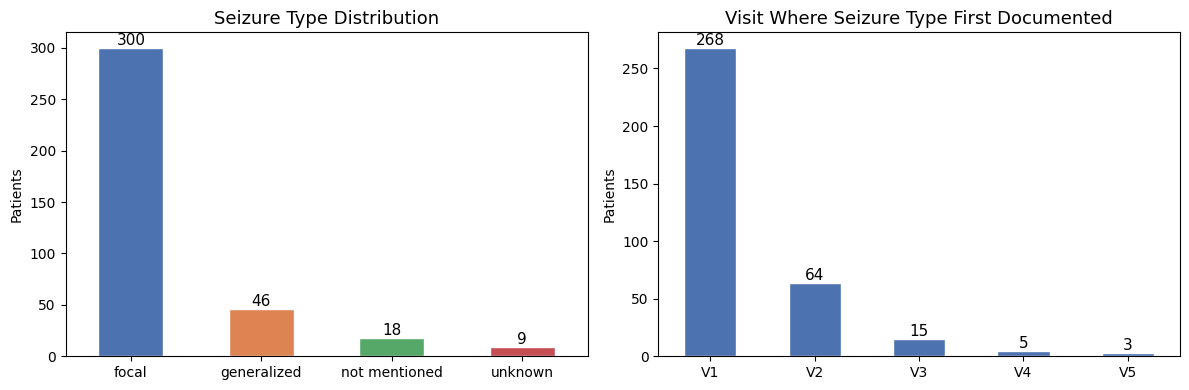

In [3]:
# Extract clean label (focal/generalized/unknown) from value like 'focal (first mentioned: V1)'
def seizure_label(val):
    val = str(val).strip().lower()
    if val.startswith('focal'):       return 'focal'
    if val.startswith('generalized'): return 'generalized'
    if val.startswith('unknown'):     return 'unknown'
    return 'not mentioned'

df['seizure_type_clean'] = df['SeizureType'].apply(seizure_label)

# Extract first-mention visit
def first_visit(val):
    m = re.search(r'V(\d)', str(val))
    return int(m.group(1)) if m else None

df['seizure_first_visit'] = df['SeizureType'].apply(first_visit)

counts = df['seizure_type_clean'].value_counts()
print(counts)
print(f'\nTotal: {len(df)}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
counts.plot.bar(ax=axes[0], color=colors[:len(counts)], edgecolor='white')
axes[0].set_title('Seizure Type Distribution', fontsize=13)
axes[0].set_xlabel('')
axes[0].set_ylabel('Patients')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=11)

visit_counts = df[df['seizure_first_visit'].notna()]['seizure_first_visit'].value_counts().sort_index()
visit_counts.index = [f'V{int(v)}' for v in visit_counts.index]
visit_counts.plot.bar(ax=axes[1], color='#4C72B0', edgecolor='white')
axes[1].set_title('Visit Where Seizure Type First Documented', fontsize=13)
axes[1].set_xlabel('')
axes[1].set_ylabel('Patients')
axes[1].tick_params(axis='x', rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

## 2. Age Distribution

Age available: 372 / 373 patients
count    372.0
mean       7.9
std        7.2
min        0.3
25%        3.0
50%        6.0
75%       10.6
max       61.0
Name: age_num, dtype: float64


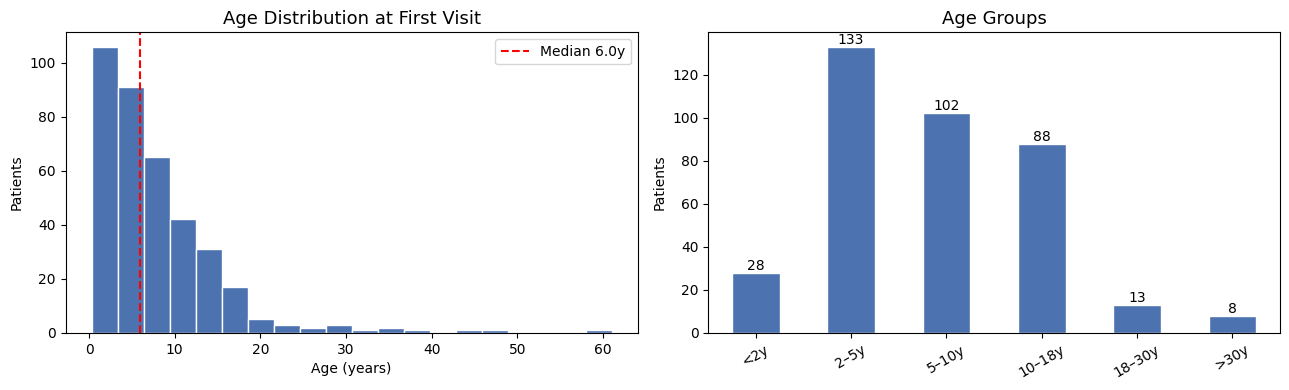

In [4]:
def parse_age(val):
    try:
        return float(str(val).strip())
    except:
        return np.nan

df['age_num'] = df['Age'].apply(parse_age)
age = df['age_num'].dropna()

print(f'Age available: {len(age)} / {len(df)} patients')
print(age.describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(age, bins=20, color='#4C72B0', edgecolor='white')
axes[0].set_title('Age Distribution at First Visit', fontsize=13)
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Patients')
axes[0].axvline(age.median(), color='red', linestyle='--', label=f'Median {age.median():.1f}y')
axes[0].legend()

bins = [0, 2, 5, 10, 18, 30, 200]
labels = ['<2y', '2–5y', '5–10y', '10–18y', '18–30y', '>30y']
df['age_group'] = pd.cut(df['age_num'], bins=bins, labels=labels, right=False)
grp = df['age_group'].value_counts().reindex(labels)
grp.plot.bar(ax=axes[1], color='#4C72B0', edgecolor='white')
axes[1].set_title('Age Groups', fontsize=13)
axes[1].set_xlabel('')
axes[1].set_ylabel('Patients')
axes[1].tick_params(axis='x', rotation=30)
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## 3. Sex Distribution

sex_clean
Male             203
Female           165
Not mentioned      5
Name: count, dtype: int64


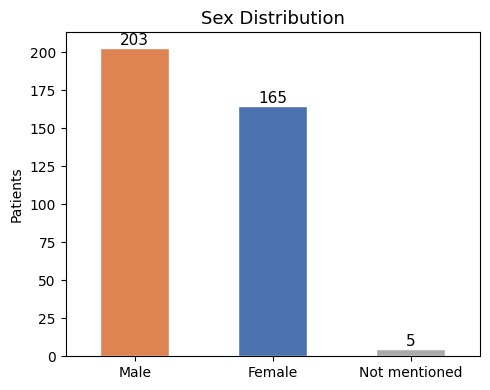

In [5]:
def parse_sex(val):
    v = str(val).strip().lower()
    if v == 'yes':  return 'Female'
    if v == 'no':   return 'Male'
    return 'Not mentioned'

df['sex_clean'] = df['Sex_Female'].apply(parse_sex)
sex_counts = df['sex_clean'].value_counts()
print(sex_counts)

fig, ax = plt.subplots(figsize=(5, 4))
sex_counts.plot.bar(ax=ax, color=['#DD8452', '#4C72B0', '#aaa'], edgecolor='white')
ax.set_title('Sex Distribution', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Patients')
ax.tick_params(axis='x', rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

## 5. Risk Factors

perinatal_complication     41
febrile_seizures           36
family_history_epilepsy    13
cerebrovascular_disease     9
trauma_to_head              7
cerebral_malaria            4
childhood_meningitis        3
dtype: int64

No risk factors: 278
Not mentioned:   1


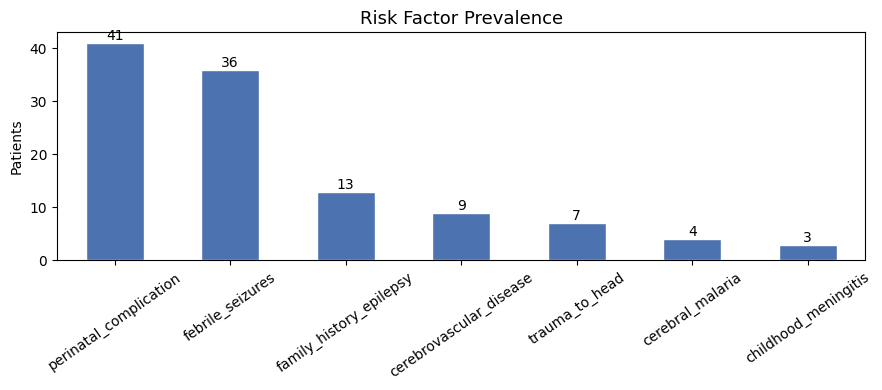

In [6]:
RISK_KEYS = [
    'febrile_seizures', 'childhood_meningitis', 'trauma_to_head',
    'perinatal_complication', 'family_history_epilepsy',
    'cerebral_malaria', 'cerebrovascular_disease',
]

risk_counts = {k: 0 for k in RISK_KEYS}
none_count  = 0

for val in df['RiskFactors']:
    val_l = str(val).lower()
    if 'none mentioned' in val_l:
        none_count += 1
        continue
    for k in RISK_KEYS:
        if k in val_l:
            risk_counts[k] += 1

rf = pd.Series(risk_counts).sort_values(ascending=False)
print(rf)
print(f'\nNo risk factors: {none_count}')
print(f'Not mentioned:   {(df["RiskFactors"].str.lower().str.startswith("not mentioned")).sum()}')

fig, ax = plt.subplots(figsize=(9, 4))
rf.plot.bar(ax=ax, color='#4C72B0', edgecolor='white')
ax.set_title('Risk Factor Prevalence', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Patients')
ax.tick_params(axis='x', rotation=35)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

## 6. Drug Usage

levetiracetam    215
carbamazepine    185
lamotrigine      101
clobazam          77
valproate         52
phenobarbital     32
topiramate        27
clonazepam         7
phenytoin          2
ethosuximide       0
dtype: int64

Total patients: 373


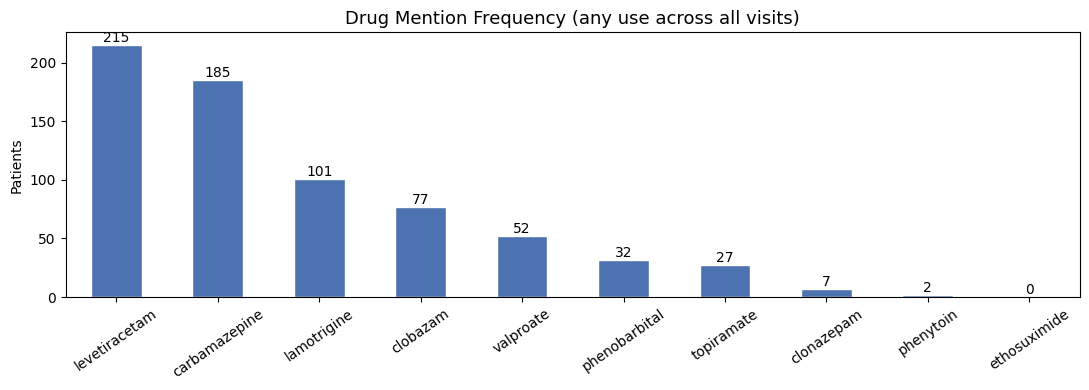

In [7]:
def drug_mentioned(val):
    v = str(val).strip().lower()
    return v != 'not mentioned.' and v != 'not mentioned'

drug_names = [d.replace('drug_', '') for d in DRUGS]
drug_counts = pd.Series(
    {name: df[f'drug_{name}'].apply(drug_mentioned).sum() for name in drug_names}
).sort_values(ascending=False)

print(drug_counts)
print(f'\nTotal patients: {len(df)}')

fig, ax = plt.subplots(figsize=(11, 4))
drug_counts.plot.bar(ax=ax, color='#4C72B0', edgecolor='white')
ax.set_title('Drug Mention Frequency (any use across all visits)', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Patients')
ax.tick_params(axis='x', rotation=35)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

n_drugs
0      2
1    161
2    129
3     55
4     19
5      5
6      1
7      1
Name: count, dtype: int64

Mean drugs per patient: 1.87


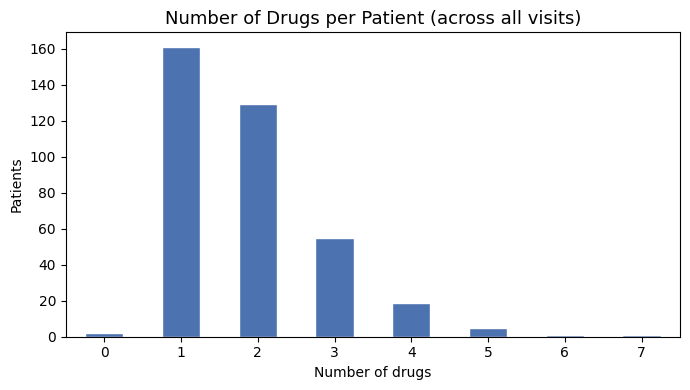

In [8]:
# Number of different drugs per patient
df['n_drugs'] = df[DRUGS].apply(lambda row: sum(drug_mentioned(v) for v in row), axis=1)

print(df['n_drugs'].value_counts().sort_index())
print(f'\nMean drugs per patient: {df["n_drugs"].mean():.2f}')

fig, ax = plt.subplots(figsize=(7, 4))
df['n_drugs'].value_counts().sort_index().plot.bar(ax=ax, color='#4C72B0', edgecolor='white')
ax.set_title('Number of Drugs per Patient (across all visits)', fontsize=13)
ax.set_xlabel('Number of drugs')
ax.set_ylabel('Patients')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## 9. Seizure Type — Patients Needing Review

In [9]:
# Patients where seizure type is first mentioned at V3+ (may have incomplete early docs)
late_mention = [
    ('ATUKUNDA VIVIAN',       'focal (first mentioned: V5)'),
    ('TENDO_ELISHA_K',        'focal (first mentioned: V5)'),
    ('BARUGAMBIRE ANGEL',     'focal (first mentioned: V5)'),
    ('NALUTAAYA FAITH',       'focal (first mentioned: V3)'),
    ('NAMBOOZE_SUZAN',        'focal (first mentioned: V3)'),
    ('BYARUHANGA_BENJAMIN',   'generalized (first mentioned: V3)'),
    ('AHIMBISIBWE ANDREA',    'focal (first mentioned: V4)'),
    ('DANIEL OTEKAT',         'focal (first mentioned: V3)'),
    ('AMAAL NSANGA',          'focal (first mentioned: V4)'),
    ('NIMARO MELLISHA',       'focal (first mentioned: V3)'),
    ('FENI NATHAN',           'focal (first mentioned: V3)'),
    ('MUDIMBE TARRIS',        'focal (first mentioned: V5)'),
    ('NKESIGA LINCOLN',       'focal (first mentioned: V3)'),
    ('MUGISHA_CALEB',         'generalized (first mentioned: V3)'),
    ('MUHANGUZI_JOSEPH',      'focal (first mentioned: V3)'),
    ('KAFUKO_MARY_PATRICIA',  'focal (first mentioned: V3)'),
    ('KASIRYE_ABDU_R',        'focal (first mentioned: V3)'),
    ('MWAMBA_MIRADI',         'focal (first mentioned: V3)'),
    ('MWEBAZE_PAUL_NC_2',     'focal (first mentioned: V3)'),
    ('KIMARA FRANCIS',        'focal (first mentioned: V3)'),
]

# Patients with genuinely ambiguous seizure semiology across all visits
unknown_type = [
    'KIMULI_YASIR',
    'NAKISEKA_SHALOM',
    'KISAKYE_ANGELLA',
    'KITIBWA_DEVINE',
    'WOGANIARA_ISAAC_2',
    'BUOM_DENG',
    'LUWAGGA SHALOM CHARIS',
    'MAGEZI JEREMIAH',
    'DWAYNE_KOGI',
    'ALVIN_KABUNGA',
    'NAPEYOK MARTHA',
    'MAYRA_ATIM',
    'MIHAYO PLACID',
    'MUHUMUZA_ISRAEL',
    'REBECCA_NAMUGULA_NC_2',
    'SAAD_BUSHIRA',
    'MUWANGUZI_PRAISE_K_2',
    'KAWOOYA_T',
]

# Patients with no seizure type found anywhere — most suspicious for eligibility
not_mentioned_type = [
    'NAMUKISA REBECCA',
    'CLAUDIA COURAGE',
    'NANDUTU_CHARITY_NC_2',
    'NANYUNJA MERCY',
    'AMPURIRE BRIAN',
    'MPUNGU RAYMOND',
    'MUBIRU_GIDEON',
    'JAZMIN_KERFUA',
    'MUKISA ISABELLA',
    'KALALA_SANA',
    'KATO MICAH',
    'NABYONGA JENIFER',
]

import pandas as pd

print(f"=== First mentioned at V3+ ({len(late_mention)}) ===")
df_late = pd.DataFrame(late_mention, columns=['Patient', 'SeizureType'])
display(df_late)

print(f"
=== Unknown seizure type ({len(unknown_type)}) ===")
print('  ' + '
  '.join(unknown_type))

print(f"
=== Seizure type not mentioned anywhere ({len(not_mentioned_type)}) — check eligibility ===")
print('  ' + '
  '.join(not_mentioned_type))

print(f"
Summary: {len(late_mention)} late-doc  |  {len(unknown_type)} unknown  |  {len(not_mentioned_type)} not mentioned")


SyntaxError: unterminated string literal (detected at line 69) (2897356377.py, line 69)

## 10. G40 ICD Code Lookup Table

In [10]:
import pandas as pd

G40_LOOKUP = {
    # Focal / Localization-related
    "G40.0":  "Localization-related idiopathic epilepsy, not intractable (unspecified)",
    "G40.00": "Localization-related idiopathic epilepsy, not intractable",
    "G40.01": "Localization-related idiopathic epilepsy, intractable",
    "G40.1":  "Localization-related symptomatic epilepsy, simple partial, unspecified",
    "G40.10": "Localization-related symptomatic epilepsy, simple partial, not intractable",
    "G40.11": "Localization-related symptomatic epilepsy, simple partial, intractable",
    "G40.20": "Localization-related symptomatic epilepsy, complex partial, not intractable",
    "G40.21": "Localization-related symptomatic epilepsy, complex partial, intractable",
    # Generalized
    "G40.3":  "Generalized idiopathic epilepsy, unspecified",
    "G40.30": "Generalized idiopathic epilepsy, not intractable",
    "G40.31": "Generalized idiopathic epilepsy, intractable",
    "G40.4":  "Other generalized epilepsy, unspecified",
    "G40.40": "Other generalized epilepsy, not intractable",
    "G40.41": "Other generalized epilepsy, intractable",
    # Special syndromes
    "G40.5":  "Special epileptic syndromes, unspecified",
    "G40.50": "Special epileptic syndromes, not intractable (e.g. Lennox-Gastaut, Dravet)",
    "G40.51": "Special epileptic syndromes, intractable",
    # Other / Unspecified
    "G40.8":  "Other epilepsy, unspecified",
    "G40.80": "Other epilepsy, not intractable — NO focal/generalized subtype specified",
    "G40.81": "Lennox-Gastaut syndrome, not intractable",
    "G40.82": "Lennox-Gastaut syndrome, intractable",
    "G40.89": "Other seizures (non-epileptic or unclassified)",
    "G40.9":  "Epilepsy unspecified",
    "G40.90": "Epilepsy unspecified, not intractable",
    "G40.91": "Epilepsy unspecified, intractable",
}

# Classification mapping
CLASSIFICATION = {
    "G40.0": "focal", "G40.00": "focal", "G40.01": "focal",
    "G40.1": "focal", "G40.10": "focal", "G40.11": "focal",
    "G40.20": "focal", "G40.21": "focal",
    "G40.3": "generalized", "G40.30": "generalized", "G40.31": "generalized",
    "G40.4": "generalized", "G40.40": "generalized", "G40.41": "generalized",
    "G40.5": "generalized", "G40.50": "generalized", "G40.51": "generalized",
    "G40.8": "unknown", "G40.80": "unknown", "G40.81": "generalized",
    "G40.82": "generalized", "G40.89": "unknown",
    "G40.9": "unknown", "G40.90": "unknown", "G40.91": "unknown",
}

# Counts from actual patient PDFs
COUNTS = {
    "G40.0": 38, "G40.00": 437, "G40.01": 349,
    "G40.1": 1,  "G40.10": 18,  "G40.11": 31,
    "G40.20": 5, "G40.21": 10,
    "G40.3": 2,  "G40.30": 21,  "G40.31": 76,
    "G40.4": 5,  "G40.40": 26,  "G40.41": 24,
    "G40.5": 5,  "G40.50": 6,
    "G40.8": 15, "G40.80": 370, "G40.81": 32, "G40.82": 2, "G40.89": 22,
    "G40.9": 20, "G40.90": 22,  "G40.91": 7,
}

df_lookup = pd.DataFrame([
    {"Code": code, "Description": desc,
     "Classification": CLASSIFICATION.get(code, "unknown"),
     "Mentions in dataset": COUNTS.get(code, 0)}
    for code, desc in G40_LOOKUP.items()
]).sort_values("Code").reset_index(drop=True)

display(df_lookup)


,Code,Description,Classification,Mentions in dataset
0,G40.0,"Localization-related idiopathic epilepsy, not intractable (unspecified)",focal,38
1,G40.00,"Localization-related idiopathic epilepsy, not intractable",focal,437
2,G40.01,"Localization-related idiopathic epilepsy, intractable",focal,349
3,G40.1,"Localization-related symptomatic epilepsy, simple partial, unspecified",focal,1
4,G40.10,"Localization-related symptomatic epilepsy, simple partial, not intractable",focal,18
5,G40.11,"Localization-related symptomatic epilepsy, simple partial, intractable",focal,31
6,G40.20,"Localization-related symptomatic epilepsy, complex partial, not intractable",focal,5
7,G40.21,"Localization-related symptomatic epilepsy, complex partial, intractable",focal,10
8,G40.3,"Generalized idiopathic epilepsy, unspecified",generalized,2
9,G40.30,"Generalized idiopathic epilepsy, not intractable",generalized,21


## 11. Genuine V1 Data Holes — Primary Diagnosis Not Epilepsy

Patients whose **first visit (V1)** document has no G40/G41 epilepsy code *and* no focal/generalized keywords.
These are genuine data holes: the seizure type could not possibly be determined from V1 alone,
either because the record is a non-epilepsy visit, or because seizures were secondary/uncertain.

Compare: **AARON_OCHWO** (F51.8 sleep disorder) — the canonical example.

In [12]:
# V1 Data Holes: patients with no G40/G41 code and no focal/gen keywords in V1
# Non-epilepsy primary diagnoses in V1 — genuine data holes

v1_holes = [
    ("AARON_OCHWO", "F51.8 sleep disorder; no epilepsy ICD in V1"),
    ("ELISHAM FILIMON", "J35.3 ENT visit; no seizure mention"),
    ("KITAMIRIKE_JESSY", "G25.3 myoclonus; coded to rule out tic"),
    ("MUSIMENTA GODFREY", "G91.1 hydrocephalus; no seizure mention"),
    ("BARUGAMBIRE ANGEL", "N39.0 UTI; ?seizures but primary dx is UTI"),
    ("MUWONGE VIANNY", "B50.9 malaria; seizures secondary to malaria"),
    ("GOODLUCK EZRA", "G80.9 cerebral palsy; epilepsy secondary to CP"),
    ("KATO ERIC", "G80.0 spastic CP; not yet confirmed as epilepsy"),
    ("YOHANNES_REZENE", "Q85.1 tuberous sclerosis; TSC-related epilepsy"),
    ("ANENA ISABELL", "R56.00 febrile convulsions; not yet coded as epilepsy"),
    ("AMAAL NSANGA", "R56.0 febrile convulsions; coded R56 not G40"),
    ("ETHAN SSEKIDDE", "R56 febrile convulsions; epilepsy type established later"),
    ("ALVIN_KABUNGA", "R62.50 failure to thrive; seizures secondary concern"),
    ("MENYA_ADRIAN", "R62.50 failure to thrive; seizures secondary concern"),
]

df_holes = pd.DataFrame(v1_holes, columns=["Patient", "Issue"])
pd.set_option("display.max_colwidth", 120)
display(df_holes)

print(f"\nTotal: {len(v1_holes)} patients with V1 data holes")
print(f"These are {len(v1_holes)/len(df) * 100:.1f}% of all {len(df)} patients")

,Patient,Issue
0,AARON_OCHWO,F51.8 sleep disorder; no epilepsy ICD in V1
1,ELISHAM FILIMON,J35.3 ENT visit; no seizure mention
2,KITAMIRIKE_JESSY,G25.3 myoclonus; coded to rule out tic
3,MUSIMENTA GODFREY,G91.1 hydrocephalus; no seizure mention
4,BARUGAMBIRE ANGEL,N39.0 UTI; ?seizures but primary dx is UTI
5,MUWONGE VIANNY,B50.9 malaria; seizures secondary to malaria
6,GOODLUCK EZRA,G80.9 cerebral palsy; epilepsy secondary to CP
7,KATO ERIC,G80.0 spastic CP; not yet confirmed as epilepsy
8,YOHANNES_REZENE,Q85.1 tuberous sclerosis; TSC-related epilepsy
9,ANENA ISABELL,R56.00 febrile convulsions; not yet coded as epilepsy



Total: 14 patients with V1 data holes
These are 3.8% of all 373 patients
